In [ ]:
%matplotlib inline
import velopotential as vp
import scanpy as sc
import matplotlib.pyplot as plt
import dynamo as dyn # To reproduce the following results, please install dynamo.
import numpy as np
import scvelo as scv
import velopotential as vp

In [2]:
adata_hsc_raw = dyn.sample_data.hematopoiesis_raw()
print(adata_hsc_raw)
selected_genes_to_use = adata_hsc_raw.uns["genes_to_use"]
preprocessor = dyn.pp.Preprocessor(force_gene_list=selected_genes_to_use)
preprocessor.config_monocle_recipe(adata_hsc_raw, n_top_genes=len(selected_genes_to_use))                             
preprocessor.preprocess_adata_monocle(
    adata_hsc_raw,
    tkey="time",
    experiment_type="one-shot",
)
adata_hsc_raw.var.use_for_pca.sum()
dyn.tl.reduceDimension(adata_hsc_raw)
dyn.tl.moments(adata_hsc_raw, group="time")
adata_hsc_raw.uns["pp"]["has_splicing"] = False
dyn.tl.dynamics(adata_hsc_raw, group="time", model="deterministic", one_shot_method="sci_fate")
dyn.tl.cell_velocities(
    adata_hsc_raw,
    enforce=True,
    X=adata_hsc_raw.layers["M_s"],
    V=adata_hsc_raw.layers["velocity_N"],
    method="cosine",
)
dyn.vf.VectorField(adata_hsc_raw, basis='umap') 
dyn.ext.ddhodge(adata_hsc_raw, basis='umap')
print(adata_hsc_raw)

|-----> Downloading raw hematopoiesis adata
|-----> File ./data\hematopoiesis_raw.h5ad already exists.
AnnData object with n_obs × n_vars = 1947 × 26193
    obs: 'batch', 'cell_type', 'time'
    var: 'gene_name_mapping'
    uns: 'genes_to_use'
    obsm: 'X_umap'
    layers: 'new', 'spliced', 'total', 'unspliced'
|-----> Running monocle preprocessing pipeline...
|-----> convert ensemble name to official gene name
|-----? Your adata object uses non-official gene names as gene index. 
Dynamo is converting those names to official gene names.
|-----> Auto-detected species: human
|-----> Conversion finished. Found 24635/26193 symbols.
|-----------> filtered out 0 outlier cells
|-----------> filtered out 23299 outlier genes
|-----> OVERWRITE all gene selection results above according to user gene list inputs. 1925 genes in use.
|-----> PCA dimension reduction
|-----> <insert> X_pca to obsm in AnnData Object.
|-----> [Preprocessor-monocle] completed [3.4477s]
|-----> retrieve data for non-line

estimating alpha: 100%|██████████| 1635/1635 [00:00<00:00, 69390.82it/s]


|-----> calculating first/second moments...
|-----> [moments calculation] completed [1.9332s]
|-----? Your adata only has labeling data, but `NTR_vel` is set to be `False`. Dynamo will reset it to `True` to enable this analysis.


estimating alpha: 100%|██████████| 1635/1635 [00:00<00:00, 38791.77it/s]



╭─ SUMMARY: dynamics ────────────────────────────────────────────────╮
│  Duration: 33.4414s                                                │
│  Shape:    1,947 x 26,193 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ use_for_dynamics (bool)                              │
│                                                                    │
│  ● UNS    │ ✚ dynamics                                             │
│           │ ✚ time_3_vel_params_names                              │
│           │ ✚ time_5_vel_params_names                              │
│                                                                    │
│  ● LAYERS │ ✚ velocity_N (sparse matrix, 1947x26193)               │
│           │ ✚ velocity_T (sparse matrix, 1947x26193)               │
│    

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering cell_type by stack threshold when stacking color because it is not a numeric type


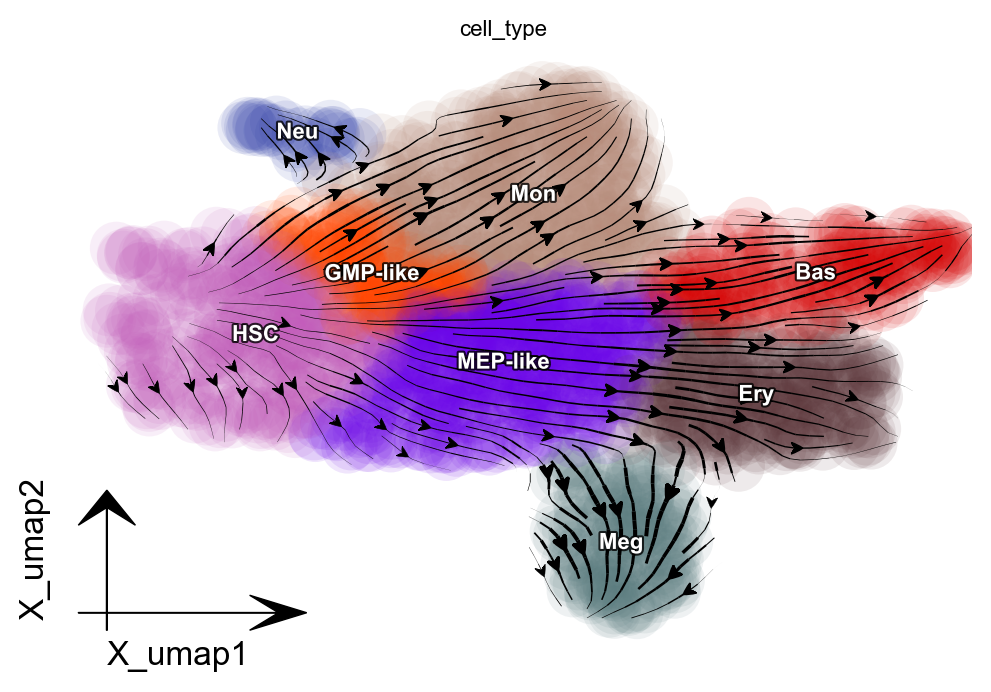

epoch   1: loss=0.456110
epoch  51: loss=0.146023
epoch 101: loss=0.127699
epoch 151: loss=0.120411
epoch 201: loss=0.116050
epoch 251: loss=0.112799
epoch 301: loss=0.110905
epoch 351: loss=0.109121
epoch 401: loss=0.107769
epoch 451: loss=0.107339
epoch 500: loss=0.106129


  0%|          | 0/1947 [00:00<?, ?cells/s]

computing velocity graph
finished.


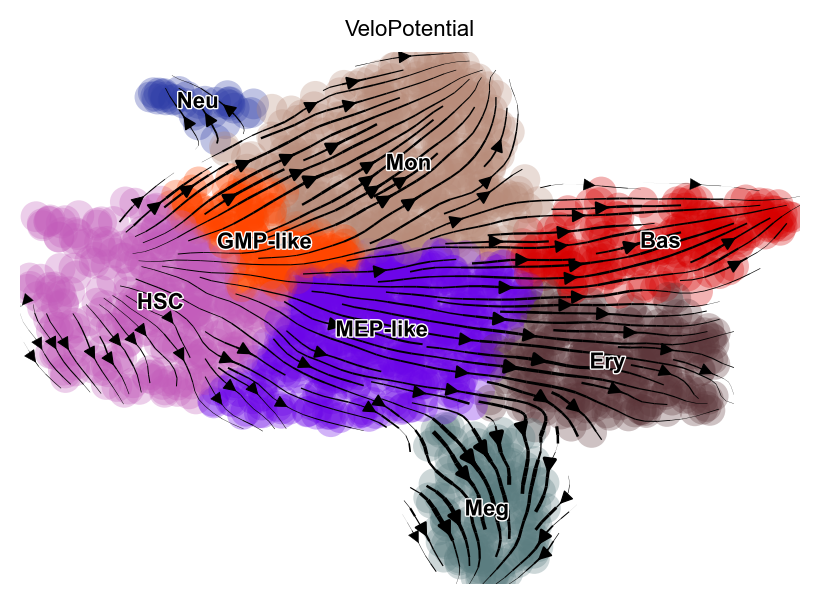

computing velocity embedding
finished.


In [ ]:
adata_hsc_raw.layers["velocity_N"]=adata_hsc_raw.layers["velocity_N"].toarray()
is_not_all_zero = ~np.all(adata_hsc_raw.layers["velocity_N"] == 0, axis=0)
adata_hsc_raw = adata_hsc_raw[:, is_not_all_zero].copy()
fig, ax = plt.subplots(figsize=(5, 3.5))
dyn.pl.streamline_plot(
    adata_hsc_raw,
    color=["cell_type"],
    ncols=1,
    basis="umap",
    figsize=(5,3.5),
    ax=ax
)
vp.tl.construct_potential(adata_hsc_raw,velocity_layer="velocity_N",input_layer="M_s")
vp.pl.plot_velocity_projection(adata_hsc_raw, basis='umap',color="cell_type",figsize=(5,3.5),vkey="velocity_pred",title="VeloPotential",xkey="M_s")

In [4]:
def potential_plot(adata):
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.interpolate import griddata
    from matplotlib.colors import LightSource
    from matplotlib.lines import Line2D

    umap1 = adata.obsm['X_umap'][:, 0]
    umap2 = adata.obsm['X_umap'][:, 1] 
    potential = adata.obs['potential'].values
    cell_types = adata.obs['cell_type'].values
    unique_clusters = np.unique(cell_types)
    auto_colors_map = {ct: adata.uns['cell_type_colors'][i] for i, ct in enumerate(adata.obs['cell_type'].cat.categories)}
    colors = [adata.uns['cell_type_colors'][i] for i in adata.obs['cell_type'].astype('category').cat.codes]
    resolution = 80
    xi = np.linspace(umap1.min() - 0.5, umap1.max() + 0.5, resolution)
    yi = np.linspace(umap2.min() - 0.5, umap2.max() + 0.5, resolution)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((umap1, umap2), potential, (Xi, Yi), method='linear')
    Zi_min = np.nanmin(potential)
    Zi = np.nan_to_num(Zi, nan=Zi_min)
    Z_range = Zi.max() - Zi.min()
    fig = plt.figure(figsize=(6,4), facecolor='white')
    ax = fig.add_subplot(111, projection='3d')
    ls = LightSource(azdeg=225, altdeg=75)
    rgb = np.ones((Zi.shape[0], Zi.shape[1], 3))
    illuminated_surface = ls.shade_rgb(rgb, Zi, vert_exag=1.2, blend_mode='overlay')
    surf = ax.plot_surface(Xi, Yi, Zi, 
                        facecolors=illuminated_surface,
                        rstride=2, cstride=2,
                        linewidth=0.15,
                        edgecolor='darkgray',
                        alpha=0.9,
                        antialiased=True,
                        shade=False)
    z_lift = Z_range * 0.04
    ax.scatter(umap1, umap2, potential + z_lift, 
               c=colors, s=5, alpha=0.85, 
               edgecolors='white', linewidth=0.1,
               depthshade=False)
    legend_elements = []
    for ct in unique_clusters:
        legend_elements.append(Line2D([0], [0], marker='o', color='w', 
                                     markerfacecolor=auto_colors_map[ct], 
                                     markersize=7, label=ct))
    ax.legend(handles=legend_elements, loc='upper left', 
             bbox_to_anchor=(0.05, 0.95), frameon=False, 
             fancybox=True, shadow=False, fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('none')
    ax.yaxis.pane.set_edgecolor('none')
    ax.zaxis.pane.set_edgecolor('none')
    ax.xaxis.pane.set_alpha(0)
    ax.yaxis.pane.set_alpha(0)
    ax.zaxis.pane.set_alpha(0)
    ax.grid(False)
    ax.xaxis.line.set_color('none')
    ax.yaxis.line.set_color('none')
    ax.zaxis.line.set_color('none')
    ax.view_init(elev=50, azim=30)
    plt.tight_layout()
    plt.show()

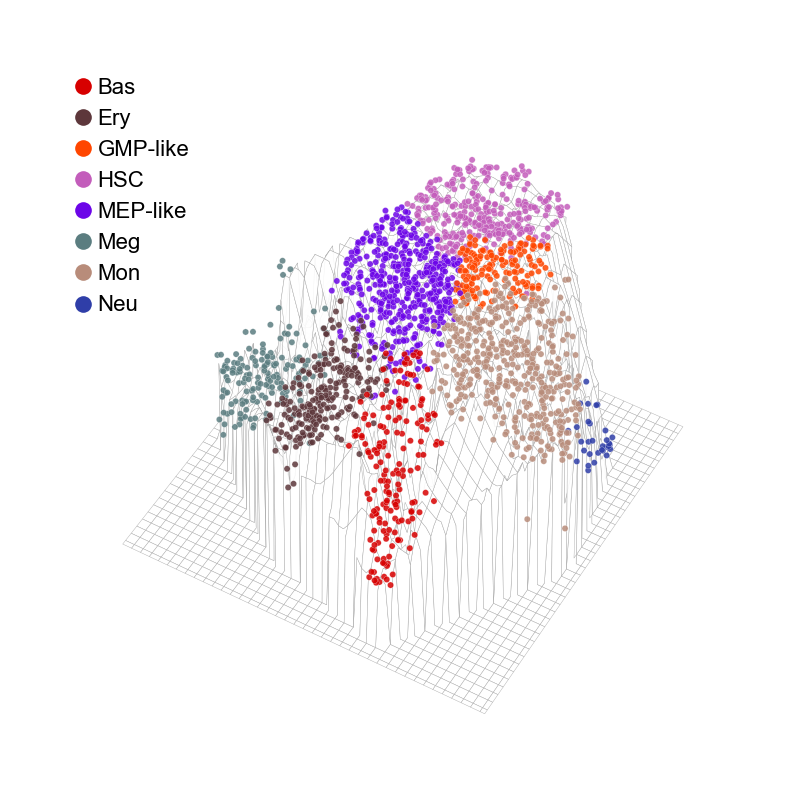

In [5]:
potential_plot(adata_hsc_raw)

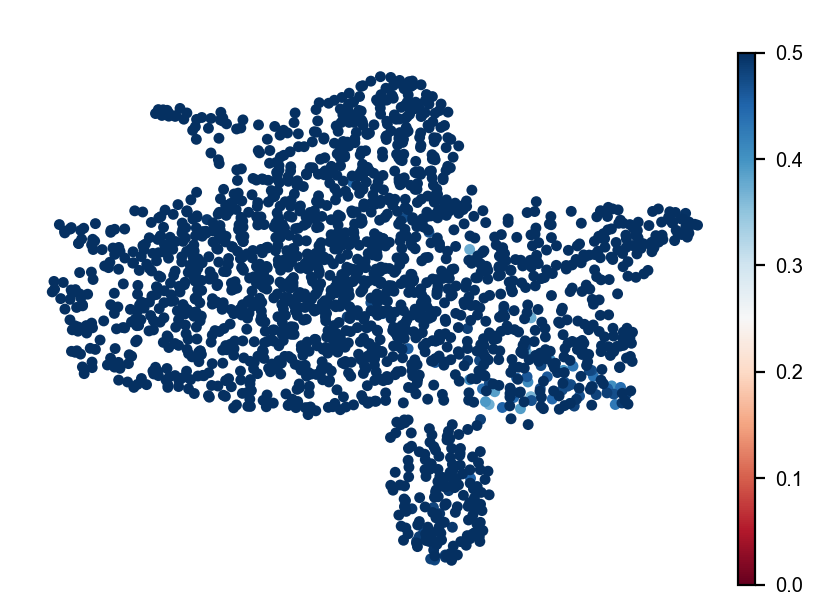

In [6]:
adata_hsc_raw.obs['Potential Consistency'] = vp.tl.cal_cosine_similarity(adata_hsc_raw.layers['velocity_N'], adata_hsc_raw.layers['velocity_pred'])
fig, ax = plt.subplots(figsize=(5, 3.5))
sc.pl.umap(adata_hsc_raw,color="Potential Consistency",title=" ",frameon=False,ax=ax,vmax=0.5,cmap="RdBu",vmin=0)

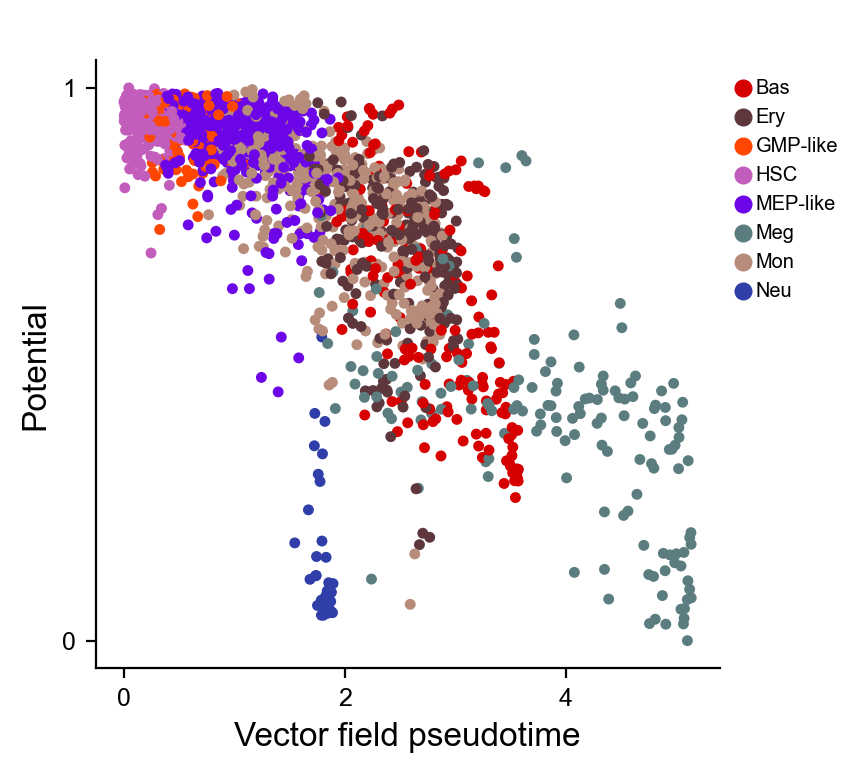

In [7]:
scv.pl.scatter(adata_hsc_raw, x='umap_ddhodge_potential', y='potential', color='cell_type',title=" ",legend_loc="upper right",fontsize=12,figsize=(4,4),xlabel="Vector field pseudotime",ylabel="Potential",show=False)
ax = plt.gca()
ax.spines['top'].set_visible(False)  
ax.spines['right'].set_visible(False) 
plt.show()